1. Chargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("../data/insider_threat_clean_dataset.csv")

2. Y'a t il des doublons à supprimer?

In [2]:
#Les doublons
print(f"Nombre de lignes en double : {df.duplicated().sum()}")

Nombre de lignes en double : 0


3. Correction des types

In [3]:
#Correction de la colonne trip_day_number en entier au lieu de float
df["trip_day_number"] = df["trip_day_number"].astype("int64")

#Vérification s'il y a des valeurs manquantes
print(df["trip_day_number"].isnull().sum())

#Nouveau type
df["trip_day_number"].dtypes


0


dtype('int64')

4. Traitement des outliers

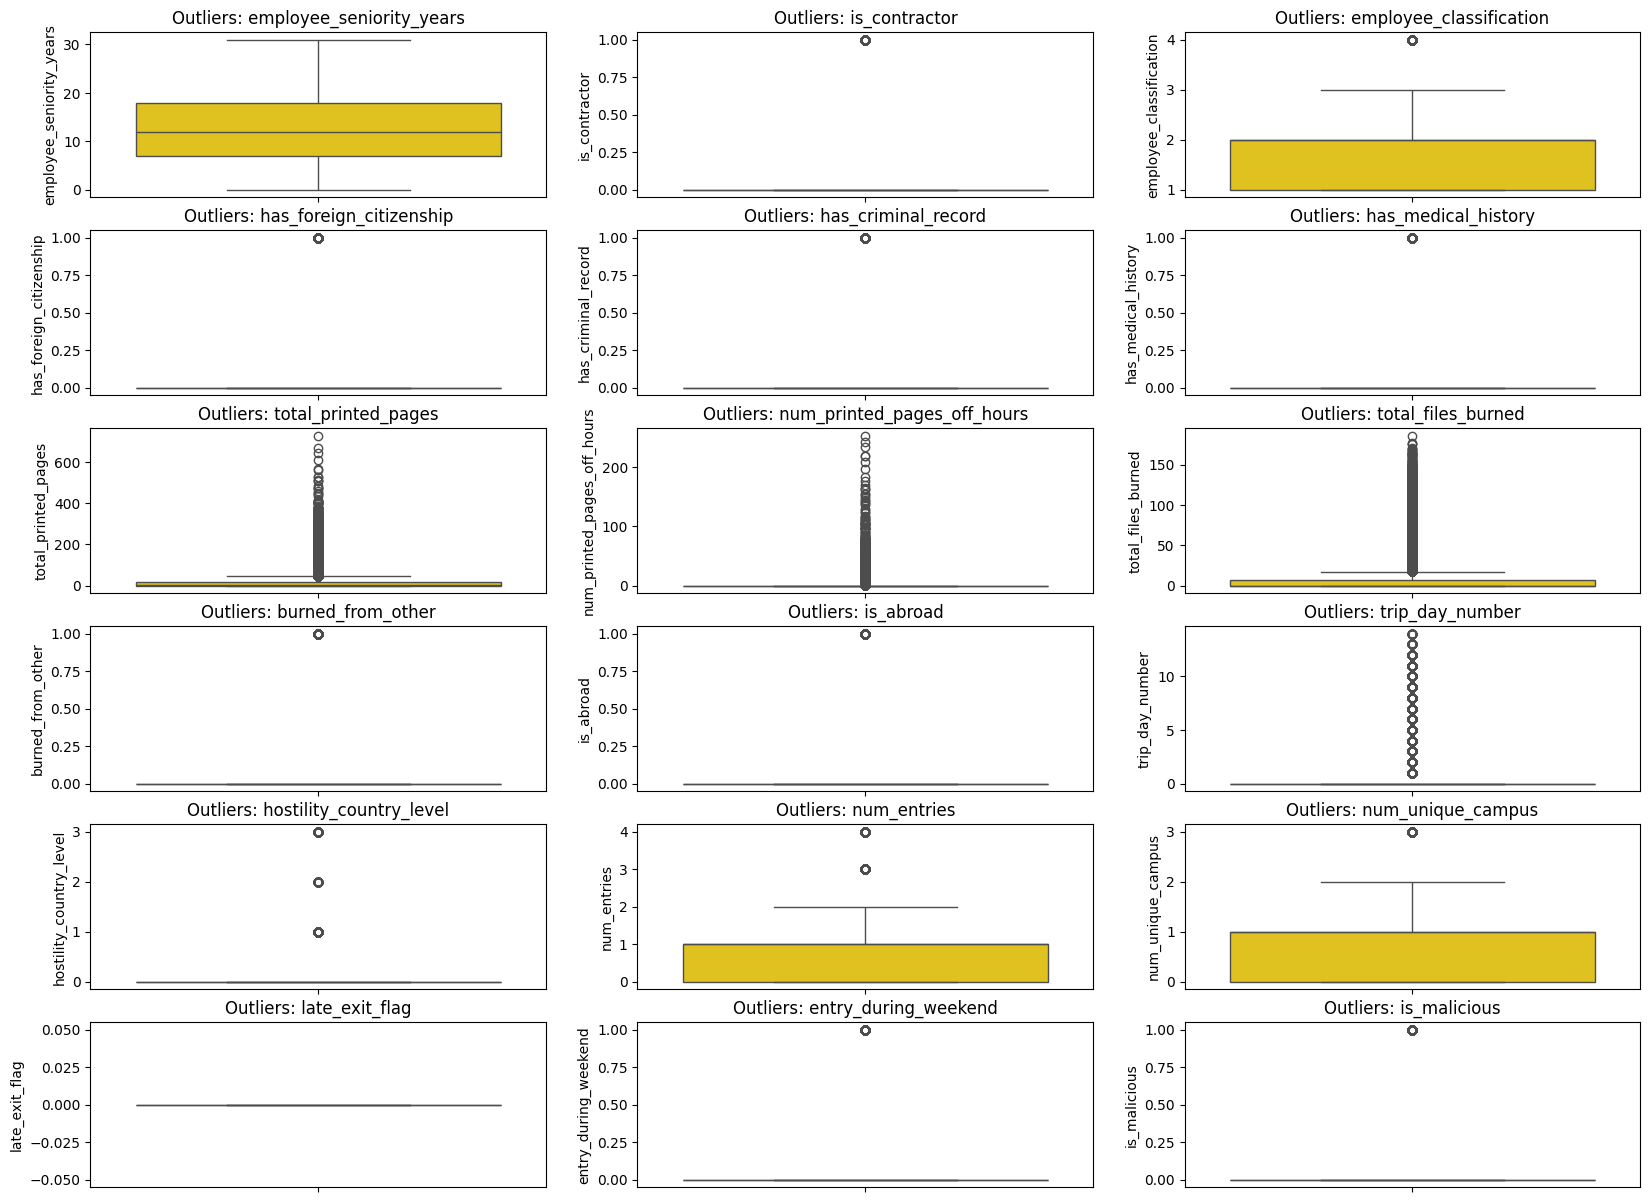

In [4]:
#Affichage des outliers
cols = df.select_dtypes(include="number").columns

# Création d'une grille de graphiques
plt.figure(figsize=(20, 15))
for i, col in enumerate(cols, 1):
    plt.subplot(6, 3, i)
    sns.boxplot(y=df[col], color="gold")
    plt.title(f"Outliers: {col}")

plt.show()


In [5]:
#Les colonnes concernées par les outliers
cols_to_clip = ["total_printed_pages",
                "num_printed_pages_off_hours",
                "total_files_burned",
                "trip_day_number"]

#Application du clipping 
for col in cols_to_clip:
    borne_basse = df[col].quantile(0.01)
    borne_haute = df[col].quantile(0.99)

    print(f"*{col}")
    print(f"Avant : min = {df[col].min()}, max = {df[col].max()}")
    print(f"Bornes : [{borne_basse} ; {borne_haute}]")

    df[col] = df[col].clip(borne_basse,borne_haute)
    print(f"Après : min = {df[col].min()}, max = {df[col].max()}")
    print()

*total_printed_pages
Avant : min = 0, max = 728
Bornes : [0.0 ; 109.0]
Après : min = 0, max = 109

*num_printed_pages_off_hours
Avant : min = 0, max = 253
Bornes : [0.0 ; 12.0]
Après : min = 0, max = 12

*total_files_burned
Avant : min = 0, max = 186
Bornes : [0.0 ; 95.0]
Après : min = 0, max = 95

*trip_day_number
Avant : min = 0, max = 14
Bornes : [0.0 ; 8.0]
Après : min = 0, max = 8



5. Encodage maintenant ?

In [6]:
#Les colonnes texte restent texte, on va faire l'encodage dans la partie entrainement
#pour eviter data leakage et le probleme de biais
print("Colonnes pour l'encodage :", df.select_dtypes("object").columns.tolist())

Colonnes pour l'encodage : ['employee_department', 'employee_campus', 'employee_position', 'employee_origin_country']


In [7]:
# AJOUTÉ — sans ça le notebook suivant ne voit pas le nettoyage
df.to_csv("../data/df_clean.csv", index=False)